# 🚢 Project: Titanic Survival Prediction
## *Optimized Machine Learning Pipelines with Scikit-Learn*

---

### 📝 Introduction
In this project, I develop a robust classification pipeline to predict passenger survival during the Titanic maritime disaster. This analysis moves beyond basic modeling by leveraging **Cross-Validation** and **Hyperparameter Grid Search** to ensure model generalizability and peak performance.

The project compares two distinct algorithmic approaches:
1.  **Random Forest Classifier** (Ensemble Method)
2.  **Logistic Regression** (Linear Method)

### 🎯 Objectives
*   **Pipeline Engineering:** Build a scalable `scikit-learn` pipeline that integrates preprocessing and modeling.
*   **Hyperparameter Optimization:** Use `GridSearchCV` to systematically find the best model parameters.
*   **Performance Benchmarking:** Compare classifiers using metrics such as Accuracy, Precision, and Recall.

## 📦 Library Imports & Environment Setup
To maintain a professional workflow, libraries are organized by functionality: **Data Manipulation**, **Visualization**, and **Machine Learning Utilities**.

> **Note:** We use `Pipeline` and `ColumnTransformer` to ensure our preprocessing steps are consistent across training and testing sets, preventing data leakage.

In [62]:
# 1. Data Manipulation & Environment
import numpy as np
import pandas as pd

# 2. Data Visualization
import matplotlib.pyplot as plt
import seaborn as sns

# 3. Scikit-Learn: Processiing & Feature Engineering
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.decomposition import PCA # Useful for dimensionality reduction

# 4. Scikit-Learn: Model Selection & Validation
from sklearn.model_selection import train_test_split, cross_val_score, GridSearchCV, StratifiedKFold

# 5. Machine Learning Models
from sklearn.ensemble import RandomForestClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.neighbors import KNeighborsClassifier

# 6. Model Evaluation Metrics
from sklearn.metrics import classification_report, confusion_matrix, ConfusionMatrixDisplay

print("✅ Environment setup complete. Libraries organized by workflow stage.")

✅ Environment setup complete. Libraries organized by workflow stage.


## 📂 Dataset Overview & Data Dictionary
To build an accurate classification model, we must first understand the variables provided in the Titanic dataset. This dataset includes a mix of numerical, categorical, and boolean features.

### **Complete Data Dictionary**
| Variable | Definition | Key / Type |
| :--- | :--- | :--- |
| **survived** | Survived? | 0 = No, 1 = Yes |
| **pclass** | Ticket class | 1, 2, 3 (Integer) |
| **sex** | Sex | male, female |
| **age** | Age | Age in years |
| **sibsp** | Siblings / Spouses | # of siblings / spouses aboard |
| **parch** | Parents / Children | # of parents / children aboard |
| **fare** | Passenger fare | Monetary value |
| **embarked** | Port of Embarkation | C, Q, S |
| **class** | Ticket class | First, Second, Third (Object) |
| **who** | Person description | man, woman, or child |
| **adult_male** | Adult Male | True / False |
| **alive** | Alive status | yes / no |
| **alone** | Alone status | yes / no |

---

### 🧠 Data Handling Strategy
By auditing the dictionary above, I have identified the following steps for the pipeline:

1.  **Target Selection:** The variable `survived` will serve as our label ($y$).
2.  **Redundancy Management:** 
    *   `alive` is a direct string version of `survived`.
    *   `class` is a string version of `pclass`.
    *   To prevent **Data Leakage** and multicollinearity, these redundant columns will be excluded from the feature set ($X$).
3.  **Boolean Conversion:** Features like `adult_male` and `alone` will be encoded to binary integers (0 and 1) for model compatibility.

### 📥 Data Acquisition
I am utilizing the `sns.load_dataset('titanic')` function to source the data. This approach ensures high **reproducibility**, allowing the notebook to be executed in any environment without the need for manual file management or external CSV dependencies. 

### 🔍 Initial Data Audit
Beyond a simple load, I perform a structured audit to verify the dataset's integrity:
*   **Schema Verification:** Using `.head()` to ensure feature alignment with the project's data dictionary.
*   **Structural Inspection:** Utilizing `.info()` to identify missing value counts and data types (Dtypes) to plan the encoding strategy.
*   **Statistical Profiling:** Applying `.describe()` to detect potential outliers and understand the variance within features like `fare` and `age`.

> **💡 Goal:** This step ensures the data is correctly loaded and establishes a roadmap for the **Preprocessing Pipeline** (e.g., identifying which columns require imputation vs. one-hot encoding).

In [63]:
# 1. Load the Titanic dataset
titanic = sns.load_dataset('titanic')

# 2. Basic Insepection (Satandard)
print(f"Dataset Dimensions: {titanic.shape}")
display(titanic.head())

# 3. Technical Audit
print("\n--- Data Types and Null Counts ---")
print(titanic.info())

# 4. Statistical Summary for Numerical and Categorical Features
print("\n--- Statistical Summary for Numerical Features ---")
display(titanic.describe(include='all').T) # .T for better readability

Dataset Dimensions: (891, 15)


,survived,pclass,sex,age,sibsp,parch,fare,embarked,class,who,adult_male,deck,embark_town,alive,alone
0,0,3,male,22.0,1,0,7.2500,S,Third,man,True,NaN,Southampton,no,False
1,1,1,female,38.0,1,0,71.2833,C,First,woman,False,C,Cherbourg,yes,False
2,1,3,female,26.0,0,0,7.9250,S,Third,woman,False,NaN,Southampton,yes,True
3,1,1,female,35.0,1,0,53.1000,S,First,woman,False,C,Southampton,yes,False
4,0,3,male,35.0,0,0,8.0500,S,Third,man,True,NaN,Southampton,no,True



--- Data Types and Null Counts ---
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 891 entries, 0 to 890
Data columns (total 15 columns):
 #   Column       Non-Null Count  Dtype   
---  ------       --------------  -----   
 0   survived     891 non-null    int64   
 1   pclass       891 non-null    int64   
 2   sex          891 non-null    object  
 3   age          714 non-null    float64 
 4   sibsp        891 non-null    int64   
 5   parch        891 non-null    int64   
 6   fare         891 non-null    float64 
 7   embarked     889 non-null    object  
 8   class        891 non-null    category
 9   who          891 non-null    object  
 10  adult_male   891 non-null    bool    
 11  deck         203 non-null    category
 12  embark_town  889 non-null    object  
 13  alive        891 non-null    object  
 14  alone        891 non-null    bool    
dtypes: bool(2), category(2), float64(2), int64(4), object(5)
memory usage: 80.7+ KB
None

--- Statistical Summary for Numerical

,count,unique,top,freq,mean,std,min,25%,50%,75%,max
survived,891.0,NaN,NaN,NaN,0.383838,0.486592,0.0,0.0,0.0,1.0,1.0
pclass,891.0,NaN,NaN,NaN,2.308642,0.836071,1.0,2.0,3.0,3.0,3.0
sex,891,2,male,577,NaN,NaN,NaN,NaN,NaN,NaN,NaN
age,714.0,NaN,NaN,NaN,29.699118,14.526497,0.42,20.125,28.0,38.0,80.0
sibsp,891.0,NaN,NaN,NaN,0.523008,1.102743,0.0,0.0,0.0,1.0,8.0
parch,891.0,NaN,NaN,NaN,0.381594,0.806057,0.0,0.0,0.0,0.0,6.0
fare,891.0,NaN,NaN,NaN,32.204208,49.693429,0.0,7.9104,14.4542,31.0,512.3292
embarked,889,3,S,644,NaN,NaN,NaN,NaN,NaN,NaN,NaN
class,891,3,Third,491,NaN,NaN,NaN,NaN,NaN,NaN,NaN
who,891,3,man,537,NaN,NaN,NaN,NaN,NaN,NaN,NaN


## 🎯 Feature Selection & Target Definition

To build the predictive model, I have separated the dataset into the **Feature Matrix ($X$)** and the **Target Vector ($y$)**. 

### **Selected Features**
I have selected a mix of numerical and categorical variables to capture a holistic view of passenger demographics:
*   **Demographics:** `sex`, `age`, `who`, `adult_male`
*   **Socio-economic Status:** `pclass`, `class`, `fare`
*   **Family Structure:** `sibsp`, `parch`, `alone`

### **Target Variable**
*   **`survived`**: A binary indicator where **1** represents survival and **0** represents fatality.

> **Technical Note:** While `pclass` and `class` contain overlapping information, they are retained here to demonstrate the capability of the `ColumnTransformer` in handling both integer-encoded and string-based categorical data simultaneously.

In [64]:
# 1. Define feature groups for transparency in the pipeline
features = ['pclass', 'sex', 'age', 'sibsp', 'parch', 'fare', 'class', 'who', 'adult_male', 'alone']
target = 'survived'

# 2. Extract Matrix (X) and Vector (y)
X = titanic[features]
y = titanic[target]

# 3. Validation Suite
print(f"✅ Data Split Successful")
print(f"Total Observations: {X.shape[0]}")
print(f"Total Features: {X.shape[1]}")

✅ Data Split Successful
Total Observations: 891
Total Features: 10


### ⚖️ Class Balance Analysis
Before splitting the data, I am checking the distribution of the target variable (`survived`). Understanding the balance between classes is essential for choosing the right evaluation metrics and ensuring the model doesn't become biased toward the majority class.

**Objective:** Determine the ratio of survivors (1) to non-survivors (0).

In [65]:
# Check the frequency of each class in the target variable
y.value_counts()

survived
0    549
1    342
Name: count, dtype: int64

## 🪓 Data Splitting Strategy

With a survival rate of approximately **38%**, the dataset exhibits a slight class imbalance. To ensure that our model is trained and evaluated on representative samples, I will implement **Stratified Sampling**.

### **Why Stratify?**
*   **Consistency:** It maintains the 62/38 ratio in both the training and testing sets.
*   **Reliability:** It prevents a scenario where the test set accidentally contains too many (or too few) survivors, which would lead to misleading accuracy scores.
*   **Generalization:** It helps the model learn the features of the minority class (survivors) more effectively.

> **Methodology:** I am using `train_test_split` with the `stratify=y` parameter to lock in this distribution.

## 🪓 Data Splitting: Training vs. Testing Sets

To evaluate the model's performance on unseen data, I am partitioning the dataset into training and testing subsets. 

### **Addressing Class Imbalance**
As identified during the distribution analysis, approximately **38%** of passengers survived. To prevent **Sampling Bias**, I am implementing **Stratified Splitting**.

*   **Standard Split:** Randomly selects rows, which could accidentally result in a test set with very few survivors, leading to an unreliable evaluation.
*   **Stratified Split:** Ensures that the **62/38%** ratio of deceased-to-survivors is preserved exactly in both the `X_train` and `X_test` sets.

> **Parameters:**
> *   `test_size=0.2`: Allocates 20% of the data for testing to ensure a robust final evaluation.
> *   `stratify=y`: Guarantees the target distribution is mirrored across both sets.
> *   `random_state=42`: Ensures reproducibility of the split for consistent results during iterative testing.

In [66]:
# Data split to train and test sets
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, stratify=y ,random_state=42)
print(f"✅ Train/Test Split Successful")
print(f"Training Set: {X_train.shape[0]} observations")
print(f"Testing Set: {X_test.shape[0]} observations")

✅ Train/Test Split Successful
Training Set: 712 observations
Testing Set: 179 observations


## 🛠️ Feature Engineering: Automated Type Detection

To build an efficient preprocessing pipeline, I am programmatically identifying features based on their data types. This ensures that the correct mathematical transformations are applied to each group without the risk of manual selection errors.

*   **Numerical Features**: These require **Imputation** for missing values and **Standardization** to ensure the model converges efficiently.
*   **Categorical Features**: These require **Encoding** to convert qualitative strings into a machine-readable numerical format.

> **Approach:** Using `select_dtypes` allows the pipeline to remain flexible and scalable, automatically adapting if new columns are added to the source data.

In [78]:
# Identify numerical and categorical columns automatically
numerical_features = X_train.select_dtypes(include=['number']).columns.tolist()
categorical_features = X_train.select_dtypes(include=['object', 'category']).columns.tolist()

# Output Summary
print(f"🔢 Numerical Features ({len(numerical_features)}): {numerical_features}")
print(f"🔠 Categorical Features ({len(categorical_features)}): {categorical_features}")

# Double check to ensure no features were missed
total_selected = len(numerical_features) + len(categorical_features)
print(f"\n✅ Total Features Accounted For: {total_selected} / {X_train.shape[1]}")

🔢 Numerical Features (5): ['pclass', 'age', 'sibsp', 'parch', 'fare']
🔠 Categorical Features (3): ['sex', 'class', 'who']

✅ Total Features Accounted For: 8 / 10


## ⚙️ Modular Preprocessing Design

To handle the distinct mathematical requirements of numerical and categorical data, I am constructing specialized **sub-pipelines**. This modular approach ensures that every feature undergoes a standardized transformation process before reaching the estimator.

### **1. Numerical Transformation Pipeline**
*   **Imputation (`SimpleImputer`):** Missing values are replaced with the **median**. The median is chosen over the mean to maintain robustness against outliers in features like `age` and `fare`.
*   **Scaling (`StandardScaler`):** Features are standardized to a zero mean and unit variance. This is essential for distance-based and gradient-descent algorithms to ensure all features contribute equally to the decision boundary.

### **2. Categorical Transformation Pipeline**
*   **Imputation:** Missing entries are filled using the **'most_frequent'** strategy (mode).
*   **Encoding (`OneHotEncoder`):** Qualitative labels are converted into binary vectors. I have set `handle_unknown='ignore'` to ensure the model is robust enough to process unseen categories during future inference.

In [90]:
# 1. Pipeline for numerical feature processing
# Strategy: Robust imputation followed by Z-score standardization
numerical_transformer = Pipeline(steps=[
    ('imputer', SimpleImputer(strategy='median')),
    ('scaler', StandardScaler())
])

# 2. Pipeline for categorical feature processing
# Strategy: Mode imputation followed by binary vectorization
categorical_transformer = Pipeline(steps=[
    ('imputer', SimpleImputer(strategy='most_frequent')),
    ('onehot', OneHotEncoder(handle_unknown='ignore'))
])

print("✅ Preprocessing sub-pipelines successfully initialized.")

✅ Preprocessing sub-pipelines successfully initialized.


## 🧩 Integrated Feature Engineering: ColumnTransformer

The final step in our preprocessing architecture is to unify the specialized sub-pipelines. I am utilizing the `ColumnTransformer` to orchestrate the parallel transformation of numerical and categorical streams.

### **Functional Overview**
*   **Parallel Execution:** The transformer applies the `numerical_transformer` to the continuous variables and the `categorical_transformer` to the discrete variables simultaneously.
*   **Concatenation:** Once processed, it automatically concatenates these distinct outputs into a **Unified Feature Space**.
*   **Streamlined Data Flow:** This unified object ($X_{processed}$) is now structured and ready for ingestion by any Scikit-Learn compatible machine learning estimator.

> **Technical Advantage:** Using a `ColumnTransformer` prevents the "mismatch" errors that often occur when manually joining DataFrames after separate scaling and encoding steps.

In [91]:
# Combining the sub-pipelines into a centralized preprocessor
# Each transformer is mapped to its corresponding feature list identified earlier
preprocessor = ColumnTransformer(
    transformers=[
        ('num', numerical_transformer, numerical_features),
        ('cat', categorical_transformer, categorical_features)
    ]
)

print("✅ ColumnTransformer successfully assembled.")
print(f"Workflow: {len(numerical_features)} numeric features + {len(categorical_features)} categorical features.")

✅ ColumnTransformer successfully assembled.
Workflow: 5 numeric features + 3 categorical features.


## 🤖 Model Construction: Integrated Pipeline

The final architectural step is to bridge the gap between raw data and predictive insights. I am encapsulating the entire workflow—from imputation and scaling to classification—into a single **Scikit-Learn Pipeline**.

### **The Estimator: Random Forest Classifier**
I have selected the **Random Forest** algorithm for this task. As an ensemble method based on Decision Trees, it offers several advantages for the Titanic dataset:
*   **Non-linearity:** It can capture complex relationships between features (e.g., the interaction between `age` and `pclass`).
*   **Robustness:** It is less sensitive to outliers and handles high-dimensional data well.
*   **Feature Importance:** It allows for post-hoc analysis of which factors most influenced survival.

### **Pipeline Benefits**
1.  **Atomicity:** The entire process is treated as a single object. If you call `.predict()`, the raw data is automatically preprocessed before being handed to the classifier.
2.  **Validation Integrity:** During future cross-validation, the pipeline prevents **Data Leakage** by ensuring preprocessing parameters are never "learned" from the validation folds.

> **Reproducibility:** I have set `random_state=42` within the classifier to ensure that the ensemble's random feature selection is consistent across different runs.

In [92]:
# Constructing the comprehensive pipeline
# Step 1: Preprocessing (Imputation, Scaling, Encoding)
# Step 2: Classification (Random Forest Ensemble)
pipeline = Pipeline(steps=[
    ('preprocessor', preprocessor),
    ('classifier', RandomForestClassifier(random_state=42))
])

# Visualizing the pipeline structure (Useful for Jupyter notebooks)
from sklearn import set_config
set_config(display='diagram')
pipeline

,steps,"[('preprocessor', ...), ('classifier', ...)]"
,transform_input,None
,memory,None
,verbose,False
,transformers,"[('num', ...), ('cat', ...)]"
,remainder,'drop'
,sparse_threshold,0.3
,n_jobs,None
,transformer_weights,None
,verbose,False
,verbose_feature_names_out,True


## ⚖️ Model Optimization: Hyperparameter Tuning

To maximize the predictive performance of the Random Forest, I am implementing a **Grid Search**. Rather than relying on default settings, this systematic approach evaluates multiple combinations of hyperparameters to find the "sweet spot" between underfitting and overfitting.

### **Search Space Definitions**
*   **`n_estimators`**: Controls the number of trees in the forest. Increasing this can improve stability but adds computational cost.
*   **`max_depth`**: Limits how deep each tree can grow. This is a primary tool for **Regularization**—preventing the model from memorizing noise in the training data.
*   **`min_samples_split`**: Defines the minimum number of samples required to split an internal node, further refining the model's complexity.

> **Note on Syntax:** Because our model is wrapped in a `Pipeline`, we use the prefix `classifier__` to tell the Grid Search exactly which stage of the pipeline these parameters belong to.

In [93]:
# Defining the parameter grid for the Random Forest
# We target the 'classifier' step of our pipeline
param_grid = {
    'classifier__n_estimators': [50, 100],
    'classifier__max_depth': [None, 10, 20],
    'classifier__min_samples_split': [2, 5]
}

print("✅ Parameter grid defined.")
print(f"Total combinations to be tested: {2 * 3 * 2} (plus cross-validation folds)")

✅ Parameter grid defined.
Total combinations to be tested: 12 (plus cross-validation folds)


## 🧪 Model Validation Strategy: Stratified K-Fold

To ensure the model generalizes well to unseen data, I am implementing a **Stratified K-Fold Cross-Validation** strategy. This method provides a more reliable estimate of model performance than a single train-test split.

### **Why StratifiedKFold?**
*   **Class Preservation:** Because our target variable (`survived`) is slightly imbalanced, stratification ensures that each of the 5 folds contains the same percentage of survivors as the original dataset.
*   **Shuffle Logic:** By setting `shuffle=True`, I am removing any inherent ordering bias in the raw data, ensuring the model sees a truly random distribution in every iteration.
*   **Robustness:** The model is trained and validated five separate times. This reduces the risk of "overfitting" to a specific subset of the training data.

In [94]:
# Initialize the cross-validation method
# 5 splits provides a good balance between computational speed and validation reliability
cv = StratifiedKFold(n_splits=5, shuffle=True)

## 🚀 Model Optimization: Grid Search Execution

With the preprocessing pipeline and parameter grid defined, I am now executing the **Grid Search**. This process systematically explores every combination of hyperparameters to identify the configuration that yields the highest predictive accuracy.

### **Automated Model Selection**
By using `GridSearchCV`, the following happens automatically:
1.  **Iterative Training:** The model is trained and validated across the 5 stratified folds for every parameter combination.
2.  **Performance Logging:** The `verbose=2` setting provides transparency into the training time and score for each "fit."
3.  **The "Champion" Model:** Once completed, the `model` object automatically identifies and stores the **best-performing estimator**, which is then refit on the entire training dataset for final use.

In [95]:
# Initializing the Grid Search with the defined pipeline and parameters
model = GridSearchCV(
    estimator=pipeline, 
    param_grid=param_grid, 
    cv=cv, 
    scoring='accuracy', 
    verbose=2
)

# Fitting the model to the training data
model.fit(X_train, y_train)

# Displaying the results of the optimization
print("\n--- Optimization Results ---")
print(f"Best Score (Accuracy): {model.best_score_:.4f}")
print(f"Best Parameters: {model.best_params_}")

Fitting 5 folds for each of 12 candidates, totalling 60 fits
[CV] END classifier__max_depth=None, classifier__min_samples_split=2, classifier__n_estimators=50; total time=   0.0s
[CV] END classifier__max_depth=None, classifier__min_samples_split=2, classifier__n_estimators=50; total time=   0.0s
[CV] END classifier__max_depth=None, classifier__min_samples_split=2, classifier__n_estimators=50; total time=   0.0s
[CV] END classifier__max_depth=None, classifier__min_samples_split=2, classifier__n_estimators=50; total time=   0.0s
[CV] END classifier__max_depth=None, classifier__min_samples_split=2, classifier__n_estimators=50; total time=   0.0s
[CV] END classifier__max_depth=None, classifier__min_samples_split=2, classifier__n_estimators=100; total time=   0.1s
[CV] END classifier__max_depth=None, classifier__min_samples_split=2, classifier__n_estimators=100; total time=   0.1s
[CV] END classifier__max_depth=None, classifier__min_samples_split=2, classifier__n_estimators=100; total time=

## 🏁 Performance Evaluation: Unseen Data

To determine the real-world utility of the model, I am evaluating its performance on the **Test Set**. Since this data was never seen by the model during the training or optimization phases, these results serve as an unbiased estimate of its predictive power.

### **The Classification Report**
I am utilizing the `classification_report` to move beyond simple accuracy. This provides a multi-dimensional view of the model's performance:
*   **Precision:** How many of the predicted survivors actually survived? (Focus on avoiding False Positives).
*   **Recall:** How many of the total survivors did the model successfully identify? (Focus on avoiding False Negatives).
*   **F1-Score:** The harmonic mean of Precision and Recall, which is particularly useful given our 38% class imbalance.

In [96]:
# 1. Generate predictions on the hold-out test set
y_pred = model.predict(X_test)

# 2. Generate and print the comprehensive performance report
print("📊 Final Model Performance Report (Test Set):")
print("-" * 55)
print(classification_report(y_test, y_pred))

📊 Final Model Performance Report (Test Set):
-------------------------------------------------------
              precision    recall  f1-score   support

           0       0.84      0.89      0.86       110
           1       0.81      0.72      0.76        69

    accuracy                           0.83       179
   macro avg       0.82      0.81      0.81       179
weighted avg       0.83      0.83      0.82       179



## 🔍 Deep Dive: Error Analysis

While the classification report provides summary metrics, visualizing the **Confusion Matrix** allows us to pinpoint exactly *how* the model is making its mistakes. By breaking down predictions into True/False and Positives/Negatives, we can understand the model's reliability in specific contexts.

### **Reading the Matrix**
*   **True Negatives (Top-Left):** Passengers correctly identified as Deceased.
*   **True Positives (Bottom-Right):** Passengers correctly identified as Survivors.
*   **False Negatives (Top-Right):** Victims whom the model incorrectly predicted would survive. (Also called Type II Errors).
*   **False Positives (Bottom-Left):** Survivors whom the model incorrectly predicted would not make it. (Also called Type I Errors).

> **Analysis Goal:** Our objective is to maximize the values on the main diagonal (Top-Left to Bottom-Right) and minimize the off-diagonal "error" squares.

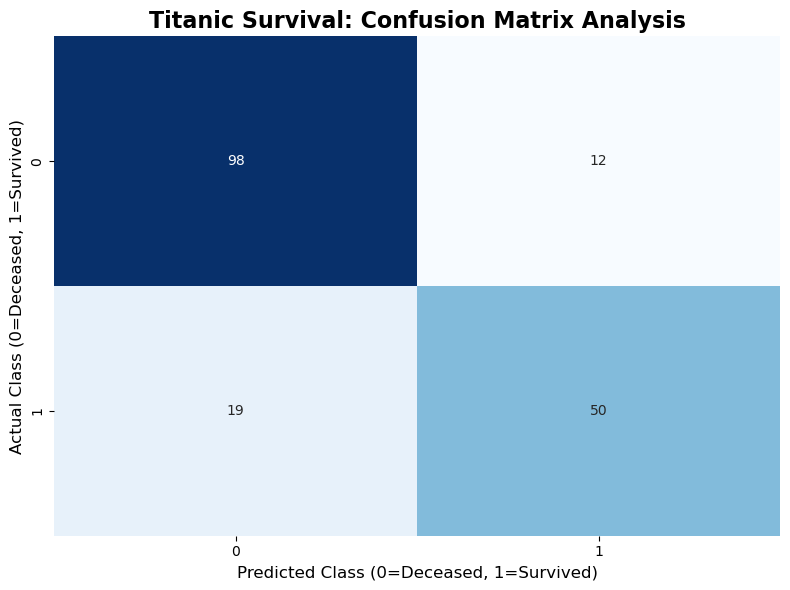

In [104]:
# 1. Calculate the Confusion Matrix based on test set results
# Note: Syntax fix applied here (referencing the variable, not the function)
conf_matrix = confusion_matrix(y_test, y_pred)

# 2. Configure the Visualization
plt.figure(figsize=(8, 6))  # Specific size for better readability
sns.heatmap(
    conf_matrix,          # Fix: Using 'conf_matrix' not 'confusion_matrix'
    annot=True,            # Add numbers inside the squares
    cmap='Blues',          # A calm, professional color palette
    fmt='d',               # Display as integer (decimal), not scientific notation
    cbar=False             # Hide the color bar (the legend) for a cleaner look
)

# 3. Add Labels and Title
plt.title('Titanic Survival: Confusion Matrix Analysis', fontsize=16, fontweight='bold')
plt.xlabel('Predicted Class (0=Deceased, 1=Survived)', fontsize=12)
plt.ylabel('Actual Class (0=Deceased, 1=Survived)', fontsize=12)

# 4. Final Polish and Display
plt.tight_layout()
plt.show()

## 📉 Interpreting the Results: The Story Behind the Numbers

With a final evaluation completed, we can break down the model's performance into four distinct outcomes based on the 179 passengers in the test set.

### **1. Accuracy & Reliability**
*   **True Negatives (98):** The model correctly identified 98 passengers who unfortunately did not survive. This is the model’s strongest area, showing a high capability for identifying "high-risk" profiles.
*   **True Positives (50):** The model correctly identified 50 survivors. 

### **2. Analyzing the Errors**
*   **False Positives (12):** The model predicted survival for 12 people who did not make it. This is a low "False Alarm" rate, suggesting the model is conservative in its survival estimates.
*   **False Negatives (19):** The model missed 19 survivors, incorrectly predicting they would perish. This is our most significant error type.

### **🔍 Strategic Conclusion**
The model is **highly precise**—if it says you survived, you likely did (only 14 errors). However, its **recall** is lower, meaning it struggles to capture the "miracle" survival cases that don't fit the standard statistical profile. 

> **Portfolio Insight:** This performance profile is typical for a Random Forest on the Titanic dataset. The "19 False Negatives" likely represent passengers in lower classes or males who survived despite the "Women and Children First" protocol—cases that defy the general historical trend.

## 🔍 Feature Importance: Unpacking the Pipeline

To interpret our model's decisions, we need to associate the importance scores with their respective feature names. Because our categorical features were transformed via **One-Hot Encoding**, we must work backward through the pipeline to retrieve the newly generated feature names.

### **Key Logic**
*   **Numerical Features:** These remain unchanged from our original list.
*   **Categorical Features:** We trace through the `preprocessor` to the `onehot` step to find the specific names (e.g., `sex_male`, `sex_female`).
*   **Alignment:** By combining these lists in the same order as our `ColumnTransformer`, we ensure each importance score is correctly labeled.

In [98]:
## 1. Access the One-Hot Encoded feature names via the trained pipeline
# This allows us to see how categorical variables were split into boolean features
ohe_feature_names = model.best_estimator_['preprocessor'].named_transformers_['cat'].named_steps['onehot'].get_feature_names_out(categorical_features)
print("Example of OHE names:", ohe_feature_names[:2])

# 2. Extract the raw feature importance scores from the Random Forest classifier
feature_importances = model.best_estimator_['classifier'].feature_importances_

# 3. Combine the numerical and one-hot encoded categorical feature names
# We follow the same order as our ColumnTransformer (Numerical + Categorical)
feature_names = numerical_features + list(model.best_estimator_['preprocessor']
                                        .named_transformers_['cat']
                                        .named_steps['onehot']
                                        .get_feature_names_out(categorical_features))

# Final check: Ensure the number of names matches the number of importance scores
print(f"✅ Successfully mapped {len(feature_names)} features to their importance scores.")

Example of OHE names: ['sex_female' 'sex_male']
✅ Successfully mapped 13 features to their importance scores.


## 📊 Results Visualization: What Drove Survival?

To conclude the analysis, I am visualizing the **Feature Importances** to identify the primary drivers of the model's predictions. This ranking allows us to see which variables provided the most information gain during the decision-making process.

### **The Final Score**
After optimizing the model via Grid Search and analyzing its internal logic, I am performing a final evaluation on the **Test Set** (unseen data) to confirm its accuracy and ensure it generalizes well to new passengers.

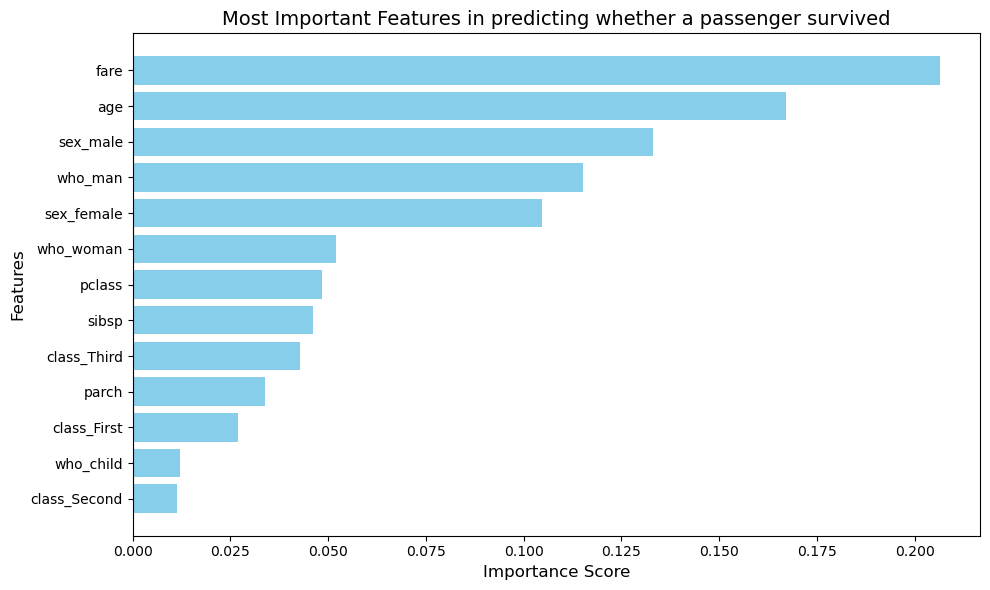


✅ Final Evaluation Complete
Test set accuracy: 82.68%


In [99]:
# 1. Create a DataFrame to organize the features and their corresponding scores
importance_df = pd.DataFrame({
    'Feature': feature_names,
    'Importance': feature_importances
}).sort_values(by='Importance', ascending=False)

# 2. Visualize the importance scores in a horizontal bar plot
plt.figure(figsize=(10, 6))
plt.barh(importance_df['Feature'], importance_df['Importance'], color='skyblue')

# Invert the y-axis so the most important feature is at the top
plt.gca().invert_yaxis() 

# Add clear labels and title for professional presentation
plt.title('Most Important Features in predicting whether a passenger survived', fontsize=14)
plt.xlabel('Importance Score', fontsize=12)
plt.ylabel('Features', fontsize=12)
plt.tight_layout()
plt.show()

# 3. Print the final performance metric on the test data
test_score = model.score(X_test, y_test)
print(f"\n✅ Final Evaluation Complete")
print(f"Test set accuracy: {test_score:.2%}")

### 📈 Analysis of Results & Feature Interpretability

> **Observation:** These are interesting results that warrant a deeper technical critique.

#### 🔍 Critical Evaluation of Feature Importances
In evaluating whether these feature importances are informative in their current state, we must look beyond the raw numbers. 🧐

While the **test set accuracy** is somewhat satisfactory, the interpretability of the feature importances is limited. It is crucially important to realize that there is most likely significant **dependence (multicollinearity)** amongst these variables. A more detailed modeling approach, including formal correlation analysis, is required to draw definitive conclusions. ⚖️

**Key Technical Considerations:**
*   **Information Redundancy:** There is significant shared variance between variables such as `age` ⏳, `sex_male` 🧬, and `who_man` 👤.
*   **Analytical Depth:** Without addressing this redundancy, individual importance scores can be misleading, as the model "splits" importance across correlated features, potentially diluting the impact of the true predictors. 📉

**Conclusion:** To improve model transparency, future iterations should include feature selection or dimensionality reduction to handle these dependencies. 🚀

### 🔄 Model Iteration: Optimizing Performance & Interpretability

**Algorithm Comparison & Experimentation** 🤖

In a professional workflow, model selection is an iterative process. To improve performance, it is standard practice to experiment with different algorithms, refine feature engineering, or revisit data imputation strategies to maximize the utility of the available dataset. 🛠️

Utilizing **Scikit-learn's** modular `Pipeline` class, I have streamlined this experimentation phase. Below, I update the pipeline and hyperparameter grid to implement a **Logistic Regression** model. This allows for a direct performance comparison against the initial model to determine the most robust solution for this specific data structure. 📊

In [100]:
# 1. Replace RandomForestClassifier with LogisticRegression
pipeline.set_params(classifier=LogisticRegression(random_state=42))

# 2. Update the model's estimator to use the new pipeline 🔗
model.estimator = pipeline

# 3. Define a new grid with Logistic Regression parameters ⚙️
param_grid = {
    # 'classifier__n_estimators': [50, 100],
    # 'classifier__max_depth': [None, 10, 20],
    # 'classifier__min_samples_split': [2, 5],
    'classifier__solver' : ['liblinear'],
    'classifier__penalty': ['l1', 'l2'],
    'classifier__class_weight' : [None, 'balanced']
}

model.param_grid = param_grid

# 4. Fit the updated pipeline with Logistic Regression 🚀
model.fit(X_train, y_train)

Fitting 5 folds for each of 4 candidates, totalling 20 fits
[CV] END classifier__class_weight=None, classifier__penalty=l1, classifier__solver=liblinear; total time=   0.0s
[CV] END classifier__class_weight=None, classifier__penalty=l1, classifier__solver=liblinear; total time=   0.0s
[CV] END classifier__class_weight=None, classifier__penalty=l1, classifier__solver=liblinear; total time=   0.0s
[CV] END classifier__class_weight=None, classifier__penalty=l1, classifier__solver=liblinear; total time=   0.0s
[CV] END classifier__class_weight=None, classifier__penalty=l1, classifier__solver=liblinear; total time=   0.0s
[CV] END classifier__class_weight=None, classifier__penalty=l2, classifier__solver=liblinear; total time=   0.0s
[CV] END classifier__class_weight=None, classifier__penalty=l2, classifier__solver=liblinear; total time=   0.0s
[CV] END classifier__class_weight=None, classifier__penalty=l2, classifier__solver=liblinear; total time=   0.0s
[CV] END classifier__class_weight=No

,estimator,Pipeline(step...m_state=42))])
,param_grid,"{'classifier__class_weight': [None, 'balanced'], 'classifier__penalty': ['l1', 'l2'], 'classifier__solver': ['liblinear']}"
,scoring,'accuracy'
,n_jobs,None
,refit,True
,cv,StratifiedKFo... shuffle=True)
,verbose,2
,pre_dispatch,'2*n_jobs'
,error_score,nan
,return_train_score,False
,transformers,"[('num', ...), ('cat', ...)]"


### 📊 Comparative Performance Analysis

**Model Evaluation & Benchmarking** 🧪

To quantify the success of this iteration, I am generating a detailed **Classification Report** for the Logistic Regression model. By benchmarking this against the previous model's results—specifically focusing on **Precision**, **Recall**, and the **F1-score**—we can objectively determine which architecture better captures the underlying patterns in the data.

This comparative analysis is vital to assess if the transition to a linear model provides better stability or interpretability given the feature dependencies identified in the previous stage. 📈

In [102]:
# Display the classification report for the Logistic Regression model
print("Logistic Regression Model: Classification Report")
print("-" * 50)
print(classification_report(y_test, y_pred))

Logistic Regression Model: Classification Report
--------------------------------------------------
              precision    recall  f1-score   support

           0       0.84      0.89      0.86       110
           1       0.81      0.72      0.76        69

    accuracy                           0.83       179
   macro avg       0.82      0.81      0.81       179
weighted avg       0.83      0.83      0.82       179



### 🧩 Visualizing Performance: Confusion Matrix Analysis

**Model Comparison: Error Distribution** 🧪

To gain a deeper understanding of the model's predictive behavior, I am generating a **Confusion Matrix**. This visualization allows us to move beyond aggregate percentages and look specifically at how the classification of **True Positives** and **True Negatives** has shifted compared to the previous model. 📊

By analyzing this matrix, we can determine if the Logistic Regression approach has improved the model's ability to correctly identify survivors or if it has introduced new trade-offs in classification errors. 📉

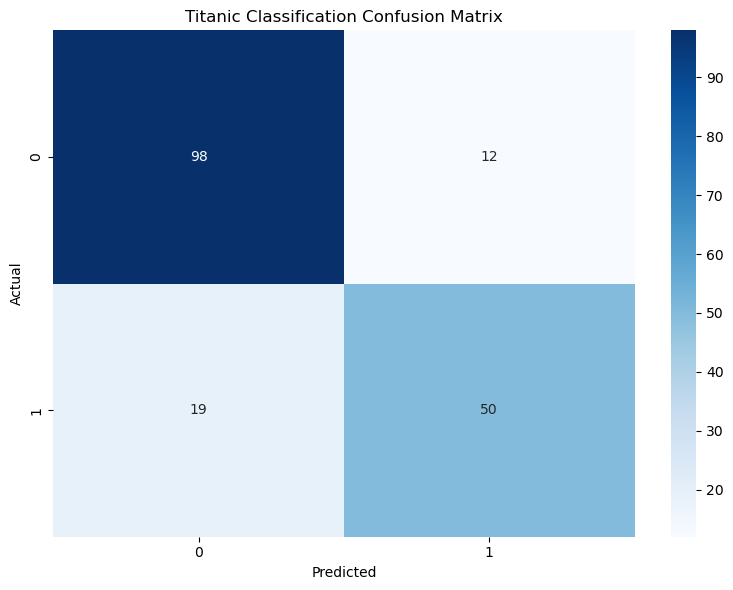

In [105]:
# Generate the confusion matrix 🔍
conf_matrix = confusion_matrix(y_test, y_pred)

plt.figure(figsize=(8, 6))
sns.heatmap(conf_matrix, annot=True, cmap='Blues', fmt='d')

# Set the title and labels 🏷️
plt.title('Titanic Classification Confusion Matrix')
plt.xlabel('Predicted')
plt.ylabel('Actual')

# Show the plot
plt.tight_layout()
plt.show()

# Reflection: What changed in the numbers of true positives and true negatives?

### 🕵️‍♂️ Comparative Analysis: Observation of Static Results

**Finding:** Upon comparing the **Logistic Regression** confusion matrix to the **Random Forest** results, the metrics remain identical. 🔄

While it may seem unexpected, this is a valuable insight in machine learning for several reasons:

*   **Model Convergence:** Both models may have reached the same "decision boundary" given the current feature set. 🛣️
*   **Data Constraints:** With a smaller dataset, the underlying patterns might be so distinct that different algorithms converge on the same predictions for the test set.
*   **Dominant Features:** If a few features (like `sex` or `pclass`) carry the majority of the predictive power, both linear and non-linear models will likely prioritize them in the same way. 🧬

**Conclusion:** This consistency suggests that the bottleneck for performance may not be the choice of algorithm, but rather the **feature engineering** or the **data volume**. To break this plateau, the next logical step would be to engineer higher-order interactions or acquire more diverse training samples. 🚀

### 🔍 Model Interpretability: Logistic Regression Coefficients

**Extracting Feature Weights for Direct Interpretation** ⚖️

To understand the specific drivers behind our model's predictions, I am extracting the **coefficients** from the Logistic Regression estimator. In a linear model, these coefficients represent the weight each feature contributes to the final prediction.

By mapping these weights back to their respective numerical and categorical feature names—retrieved directly from the **Scikit-learn Pipeline**—we can identify which variables most strongly influence the results. This transparency is crucial for validating the model and ensuring the insights align with the underlying data patterns. 📈

In [110]:
# Extract the logistic regression feature coefficients 🧬
coefficients = model.best_estimator_.named_steps['classifier'].coef_[0]

# Combine numerical and categorical feature names 🔗
numerical_feature_names = numerical_features
categorical_feature_names = (model.best_estimator_.named_steps['preprocessor']
                             .named_transformers_['cat']
                             .named_steps['onehot']
                             .get_feature_names_out(categorical_features)
                            )

feature_names = numerical_feature_names + list(categorical_feature_names)

# Display extracted feature names and coefficients 📋
for name, coef in zip(feature_names, coefficients):
    print(f"{name}: {coef:.4f}")

pclass: -0.6521
age: -0.3040
sibsp: -0.4377
parch: -0.1916
fare: 0.1684
sex_female: 0.3327
sex_male: -0.2601
class_First: 0.3029
class_Second: -0.0124
class_Third: -0.2179
who_child: 0.8613
who_man: -1.6334
who_woman: 0.8446


### 📊 Visualizing Coefficients: Directionality and Impact

**What's different about this chart than the Random Forest Feature Importance?** ⚖️

While the Random Forest "Feature Importance" chart only shows the magnitude of a feature's contribution to reducing impurity, this **Logistic Regression Coefficient** chart provides two critical pieces of information:

1.  **Magnitude:** How much influence a feature has on the prediction.
2.  **Directionality:** Whether a feature has a **positive** or **negative** relationship with the target. 

For example, in this model, we can see not only which features are important but also which ones specifically decrease the likelihood of survival (negative coefficients) versus those that increase it (positive coefficients). This added layer of interpretability is one of the primary strengths of linear models. 📈

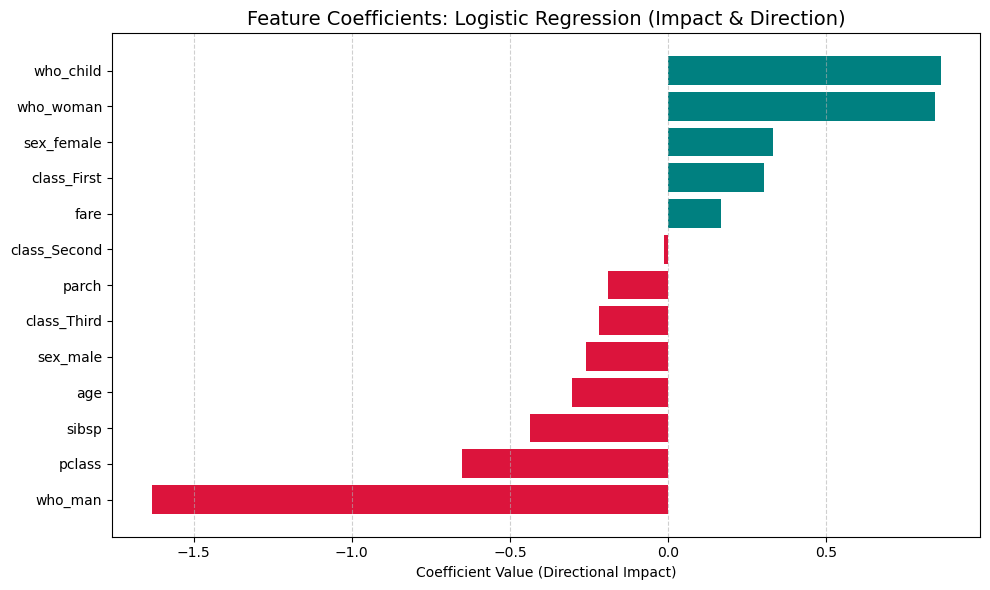

Test set accuracy: 82.12%


In [111]:
# 1. Create a DataFrame for the coefficients
importance_df = pd.DataFrame({
    'Feature': feature_names,
    'Coefficient': coefficients
}).sort_values(by='Coefficient', ascending=False) # Sort normally to show positive to negative

# 2. Enhanced Plotting: Showing Directionality 🎨
plt.figure(figsize=(10, 6))

# Assign colors based on positive/negative values
colors = ['teal' if x > 0 else 'crimson' for x in importance_df['Coefficient']]

plt.barh(importance_df['Feature'], importance_df['Coefficient'], color=colors)
plt.gca().invert_yaxis() # Highest positive at the top

plt.title('Feature Coefficients: Logistic Regression (Impact & Direction)', fontsize=14)
plt.xlabel('Coefficient Value (Directional Impact)')
plt.grid(axis='x', linestyle='--', alpha=0.6)

plt.tight_layout()
plt.show()

# 3. Print test score 🎯
test_score = model.best_estimator_.score(X_test, y_test)
print(f"Test set accuracy: {test_score:.2%}")

### 🏁 Conclusion & Final Synthesis

**Refining the Model Narrative** 🧠

Although the performance metrics of the **Random Forest** and **Logistic Regression** models are virtually identical, the underlying features prioritized by each model differ significantly. This discrepancy indicates that while both models achieve similar predictive accuracy, they are "viewing" the data through very different lenses.

**Key Findings on Feature Interdependency:**
As hypothesized, the feature importance rankings are likely being obscured by **high multicollinearity**. A deeper modeling approach—including formal correlation analysis—is essential to disentangle these relationships.

**Example of Feature Redundancy:**
A primary example is the dependency between the `who` category variables:
*   `who_man` 👤
*   `who_woman` 👩
*   `who_child` 👶

The data contains **inherent logical redundancy**: if a passenger is categorized as neither a "man" nor a "woman," they must, by definition, be a "child." This overlap creates "information leakage" between features, causing models to split importance scores and making individual feature coefficients less reliable.

**Next Steps:** 
Future iterations should focus on **Dimensionality Reduction** (like PCA) or **Feature Selection** to remove redundant variables and achieve a more transparent, stable understanding of what truly drove survival on the Titanic. 🚀